# Lab 10 — Reward Design for Wordle RL

**Goal:** design and validate the reward signal before doing reinforcement learning.

Lab 11 will optimize whatever reward we hand it.

That means a badly designed reward is not a minor implementation bug. It is the objective.

This lab answers:

> What behavior do we actually want the policy to optimize?

We will compare several reward designs:

1. sparse solve-only reward;
2. format and legality rewards;
3. history-consistency reward;
4. candidate-reduction reward;
5. terminal efficiency reward;
6. a combined shaped reward.

Then we will test whether those rewards rank good and bad trajectories sensibly.

No model training happens in this notebook.

## 10.1 Why reward design comes before RL

In supervised learning, the target tells the model what answer to imitate.

In reinforcement learning, the reward only says how good an outcome was.

That creates a new failure mode:

```text
we intended behavior A
        ↓
we wrote reward B
        ↓
optimizer becomes very good at B
```

This is often called **reward hacking** or specification gaming.

For Wordle, examples are easy to imagine:

- rewarding valid formatting but not progress;
- rewarding information gain without solving;
- rewarding non-repetition without respecting feedback;
- rewarding candidate reduction so strongly that the model ignores turn efficiency.

Lab 10 exists so Lab 11 does not optimize nonsense very efficiently.

## 10.2 Load the exact Wordle environment

Reuse the symbolic infrastructure from Labs 03 and 05.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tiny_wordle.game import Turn, filter_candidates, score_string
from tiny_wordle.expert import EntropyExpert

DATA_DIR = Path("../data")

ANSWERS = [
    line.strip().upper()
    for line in (DATA_DIR / "wordle-answers-original.txt").read_text().splitlines()
    if line.strip()
]

PATTERNS = np.load(
    DATA_DIR / "wordle-patterns-original-2315.npy"
)

expert = EntropyExpert(
    ANSWERS,
    PATTERNS,
)

WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

print("answers:", len(ANSWERS))
print("pattern matrix:", PATTERNS.shape)

answers: 2315
pattern matrix: (2315, 2315)


## 10.3 Define one action result

For reward design, we want more than just guess/feedback.

Each action should expose:

- whether formatting was valid;
- whether the guess repeated;
- whether it respected history;
- candidates before;
- candidates after;
- whether the game was solved.

This is exactly the information a reward function might use.

In [2]:
@dataclass
class ActionResult:
    guess: str | None
    feedback: str | None
    valid_format: bool
    repeated: bool
    history_consistent: bool
    solved: bool
    candidates_before: int
    candidates_after: int

def candidate_indices_from_history(
    history: list[Turn],
) -> np.ndarray:
    if not history:
        return ALL_INDICES.copy()

    survivors = filter_candidates(
        ANSWERS,
        history,
    )

    return np.asarray(
        [WORD_TO_INDEX[w] for w in survivors],
        dtype=np.int32,
    )

## 10.4 Evaluate one proposed action

This helper treats the Wordle environment as ground truth.

A guess can be:

- invalid format;
- repeated;
- inconsistent with prior feedback;
- valid but strategically weak;
- solved.

The reward function itself comes later.

In [3]:
def evaluate_action(
    answer: str,
    history: list[Turn],
    guess: str | None,
) -> ActionResult:
    candidates_before = candidate_indices_from_history(history)

    if (
        guess is None
        or len(guess) != 5
        or not guess.isalpha()
    ):
        return ActionResult(
            guess=guess,
            feedback=None,
            valid_format=False,
            repeated=False,
            history_consistent=False,
            solved=False,
            candidates_before=len(candidates_before),
            candidates_after=len(candidates_before),
        )

    guess = guess.upper()

    repeated = any(
        turn.guess == guess
        for turn in history
    )

    history_consistent = all(
        score_string(
            guess,
            old.guess,
        ) == old.feedback
        for old in history
    )

    feedback = score_string(
        answer,
        guess,
    )

    new_history = history + [
        Turn(
            guess=guess,
            feedback=feedback,
        )
    ]

    candidates_after = candidate_indices_from_history(
        new_history
    )

    return ActionResult(
        guess=guess,
        feedback=feedback,
        valid_format=True,
        repeated=repeated,
        history_consistent=history_consistent,
        solved=feedback == "GGGGG",
        candidates_before=len(candidates_before),
        candidates_after=len(candidates_after),
    )

## 10.5 Smoke-test the action evaluator

In [4]:
history = [
    Turn(
        "CRANE",
        score_string("PLANT", "CRANE"),
    )
]

for guess in [
    "PLANT",
    "CRAKE",
    "CRANE",
    "cute",
    None,
]:
    result = evaluate_action(
        "PLANT",
        history,
        guess,
    )

    print(guess, result)

PLANT ActionResult(guess='PLANT', feedback='GGGGG', valid_format=True, repeated=False, history_consistent=True, solved=True, candidates_before=16, candidates_after=1)
CRAKE ActionResult(guess='CRAKE', feedback='BBGBB', valid_format=True, repeated=False, history_consistent=False, solved=False, candidates_before=16, candidates_after=9)
CRANE ActionResult(guess='CRANE', feedback='BBGGB', valid_format=True, repeated=True, history_consistent=False, solved=False, candidates_before=16, candidates_after=16)
cute ActionResult(guess='cute', feedback=None, valid_format=False, repeated=False, history_consistent=False, solved=False, candidates_before=16, candidates_after=16)
None ActionResult(guess=None, feedback=None, valid_format=False, repeated=False, history_consistent=False, solved=False, candidates_before=16, candidates_after=16)


## 10.6 Reward 1 — sparse solve-only reward

The simplest possible objective:

```text
+1 if solved
 0 otherwise
```

This reward is perfectly aligned with the final goal.

It is also extremely sparse.

At the beginning of training, most generated actions will receive exactly zero.

In [5]:
def reward_solve_only(
    action: ActionResult,
) -> float:
    return 1.0 if action.solved else 0.0

Sparse rewards are attractive because they are hard to game.

But they provide weak credit assignment:

```text
turn 1 good guess → 0
turn 2 good guess → 0
turn 3 solve      → 1
```

The optimizer has to infer which earlier actions contributed to the success.

## 10.7 Reward 2 — format reward

A tiny reward for producing the interface contract correctly:

```text
valid five-letter output → +0.05
invalid output           → -0.25
```

This should be a small shaping term, not the objective.

Otherwise the policy could learn:

```text
CRANE
CRANE
CRANE
...
```

and collect reward for formatting while accomplishing nothing.

In [6]:
def reward_format(
    action: ActionResult,
) -> float:
    return (
        0.05
        if action.valid_format
        else -0.25
    )

## 10.8 Reward 3 — repetition penalty

Repeated guesses waste a turn and previously dominated the baseline.

Use:

```text
repeat → -0.20
```

Again: this is shaping, not the main reward.

In [7]:
def reward_repeat(
    action: ActionResult,
) -> float:
    return (
        -0.20
        if action.repeated
        else 0.0
    )

## 10.9 Reward 4 — history consistency

Lab 04 measured 0% history consistency for the baseline.

So reward consistent actions directly:

```text
history-consistent guess → +0.15
inconsistent guess       → -0.15
```

Only apply this when there is prior history and the output format is valid.

In [8]:
def reward_history_consistency(
    action: ActionResult,
    *,
    has_history: bool,
) -> float:
    if (
        not has_history
        or not action.valid_format
    ):
        return 0.0

    return (
        0.15
        if action.history_consistent
        else -0.15
    )

## 10.10 Reward 5 — candidate reduction

A useful action should reduce uncertainty.

A raw candidate-count reduction:

```text
before - after
```

is badly scaled because early turns can eliminate thousands of words while late turns eliminate only one or two.

Use logarithmic reduction instead:

```text
log(before / after)
```

That measures multiplicative progress.

In [9]:
def candidate_reduction_value(
    action: ActionResult,
) -> float:
    before = action.candidates_before
    after = action.candidates_after

    if (
        not action.valid_format
        or before <= 0
        or after <= 0
    ):
        return 0.0

    return math.log(
        before / after
    )

Let's inspect the scale.

In [10]:
history = []

for guess in [
    "RAISE",
    "FUZZY",
]:
    action = evaluate_action(
        "PLANT",
        history,
        guess,
    )

    print(
        guess,
        "before=", action.candidates_before,
        "after=", action.candidates_after,
        "log reduction=",
        candidate_reduction_value(action),
    )

RAISE before= 2315 after= 92 log reduction= 3.225376389471294
FUZZY before= 2315 after= 1352 log reduction= 0.537824709917425


Normalize this into a bounded shaping reward:

```text
candidate progress reward
  = 0.20 × tanh(log(before/after))
```

Bounding matters because RL optimizers can overfocus on a single large reward component.

In [11]:
def reward_candidate_progress(
    action: ActionResult,
) -> float:
    value = candidate_reduction_value(
        action
    )

    return 0.20 * math.tanh(
        value
    )

## 10.11 Reward 6 — terminal solve bonus

Solving should dominate all shaping terms.

Use:

```text
solve bonus = +2.0
```

This prevents the policy from preferring endless information gathering over actually winning.

In [12]:
def reward_solve_bonus(
    action: ActionResult,
) -> float:
    return (
        2.0
        if action.solved
        else 0.0
    )

## 10.12 Reward 7 — turn efficiency

Among solved games, fewer turns are better.

A small terminal bonus:

```text
turn 1 → +0.50
turn 2 → +0.40
...
turn 6 →  0.00
```

Only apply it when the answer is solved.

In [13]:
def reward_turn_efficiency(
    action: ActionResult,
    turn_number: int,
) -> float:
    if not action.solved:
        return 0.0

    return max(
        0.0,
        0.10 * (6 - turn_number),
    )

## 10.13 Combined shaped reward

Now combine the pieces.

A reasonable first design:

```text
format                   ± small
repeat                   negative
history consistency      ± moderate
candidate progress       positive
solve                    large positive
fast solve               small terminal bonus
```

The solve bonus must remain dominant.

In [14]:
@dataclass
class RewardBreakdown:
    format: float
    repeat: float
    history: float
    progress: float
    solve: float
    efficiency: float

    @property
    def total(self) -> float:
        return (
            self.format
            + self.repeat
            + self.history
            + self.progress
            + self.solve
            + self.efficiency
        )

def shaped_reward(
    action: ActionResult,
    *,
    turn_number: int,
    has_history: bool,
) -> RewardBreakdown:
    return RewardBreakdown(
        format=reward_format(action),
        repeat=reward_repeat(action),
        history=reward_history_consistency(
            action,
            has_history=has_history,
        ),
        progress=reward_candidate_progress(
            action
        ),
        solve=reward_solve_bonus(
            action
        ),
        efficiency=reward_turn_efficiency(
            action,
            turn_number,
        ),
    )

## 10.14 Compare actions from the same state

Take:

```text
answer = PLANT
history = CRANE -> BBGGB
```

Compare:

- `PLANT` — solves;
- `SLANT` — valid and consistent;
- `CRAKE` — inconsistent;
- `CRANE` — repeated;
- malformed output.

In [15]:
answer = "PLANT"

history = [
    Turn(
        "CRANE",
        score_string(
            answer,
            "CRANE",
        ),
    )
]

guesses = [
    "PLANT",
    "SLANT",
    "CRAKE",
    "CRANE",
    None,
]

rows = []

for guess in guesses:
    action = evaluate_action(
        answer,
        history,
        guess,
    )

    reward = shaped_reward(
        action,
        turn_number=2,
        has_history=True,
    )

    rows.append({
        "guess": guess,
        "valid": action.valid_format,
        "repeat": action.repeated,
        "consistent": action.history_consistent,
        "before": action.candidates_before,
        "after": action.candidates_after,
        "solved": action.solved,
        "format_r": reward.format,
        "repeat_r": reward.repeat,
        "history_r": reward.history,
        "progress_r": reward.progress,
        "solve_r": reward.solve,
        "efficiency_r": reward.efficiency,
        "total": reward.total,
    })

reward_df = (
    pd.DataFrame(rows)
    .sort_values(
        "total",
        ascending=False,
    )
)

reward_df

,guess,valid,repeat,consistent,before,after,solved,format_r,repeat_r,history_r,progress_r,solve_r,efficiency_r,total
0,PLANT,True,False,True,16,1,True,0.05,0.0,0.15,0.198444,2.0,0.4,2.798444
1,SLANT,True,False,True,16,1,False,0.05,0.0,0.15,0.198444,0.0,0.0,0.398444
2,CRAKE,True,False,False,16,9,False,0.05,0.0,-0.15,0.103858,0.0,0.0,0.003858
4,NaN,False,False,False,16,16,False,-0.25,0.0,0.00,0.000000,0.0,0.0,-0.250000
3,CRANE,True,True,False,16,16,False,0.05,-0.2,-0.15,0.000000,0.0,0.0,-0.300000


The expected ordering is roughly:

```text
solve correctly
    >
valid + useful
    >
valid but weak
    >
inconsistent / repeated
    >
malformed
```

If the table violates that ordering, fix the reward before moving on.

## 10.15 Reward trajectories, not just actions

RL eventually optimizes sequence-level behavior.

Define a trajectory as a sequence of proposed guesses.

We accumulate per-turn shaped reward.

In [16]:
@dataclass
class TrajectoryResult:
    answer: str
    guesses: list[str | None]
    solved: bool
    turns_used: int
    total_reward: float
    turn_rewards: list[float]
    breakdowns: list[RewardBreakdown]

def score_trajectory(
    answer: str,
    guesses: list[str | None],
    max_turns: int = 6,
) -> TrajectoryResult:
    history: list[Turn] = []
    turn_rewards = []
    breakdowns = []
    solved = False
    turns_used = 0

    for turn_number, guess in enumerate(
        guesses[:max_turns],
        1,
    ):
        turns_used = turn_number

        action = evaluate_action(
            answer,
            history,
            guess,
        )

        reward = shaped_reward(
            action,
            turn_number=turn_number,
            has_history=bool(history),
        )

        turn_rewards.append(
            reward.total
        )

        breakdowns.append(
            reward
        )

        if (
            action.valid_format
            and action.feedback is not None
        ):
            history.append(
                Turn(
                    guess=action.guess,
                    feedback=action.feedback,
                )
            )

        if action.solved:
            solved = True
            break

    return TrajectoryResult(
        answer=answer,
        guesses=guesses,
        solved=solved,
        turns_used=turns_used,
        total_reward=float(
            sum(turn_rewards)
        ),
        turn_rewards=turn_rewards,
        breakdowns=breakdowns,
    )

## 10.16 Hand-build good and bad trajectories

We want obvious examples before statistical analysis.

For `PLANT`:

```text
GOOD
RAISE → FLOAT → PLANT

REPEAT
CRANE → CRANE → CRANE → ...

INCONSISTENT
CRANE → CRAKE → ...

INVALID
garbage outputs

SLOW SOLVE
several valid guesses, then PLANT
```

In [17]:
trajectories = {
    "good": [
        "RAISE",
        "FLOAT",
        "PLANT",
    ],
    "repeat": [
        "CRANE",
        "CRANE",
        "CRANE",
        "CRANE",
        "CRANE",
        "CRANE",
    ],
    "inconsistent": [
        "CRANE",
        "CRAKE",
        "CRAKE",
        "CRAKE",
        "CRAKE",
        "CRAKE",
    ],
    "invalid": [
        None,
        None,
        None,
        None,
        None,
        None,
    ],
    "slow_solve": [
        "RAISE",
        "TANGY",
        "CAPUT",
        "BATCH",
        "HATCH",
        "PLANT",
    ],
}

trajectory_rows = []

for name, guesses in trajectories.items():
    result = score_trajectory(
        "PLANT",
        guesses,
    )

    trajectory_rows.append({
        "trajectory": name,
        "solved": result.solved,
        "turns": result.turns_used,
        "reward": result.total_reward,
        "turn_rewards": result.turn_rewards,
    })

trajectory_df = (
    pd.DataFrame(
        trajectory_rows
    )
    .sort_values(
        "reward",
        ascending=False,
    )
)

trajectory_df

,trajectory,solved,turns,reward,turn_rewards
0,good,True,3,3.149322,"[0.24936926301058054, 0.39995274660366215, 2.5]"
4,slow_solve,True,6,2.369180,"[0.24936926301058054, 0.0998110533774209, 0.02..."
2,inconsistent,False,6,-0.946162,"[0.2499808936723537, 0.003857566765578635, -0...."
1,repeat,False,6,-1.250019,"[0.2499808936723537, -0.30000000000000004, -0...."
3,invalid,False,6,-1.500000,"[-0.25, -0.25, -0.25, -0.25, -0.25, -0.25]"


## 10.17 Reward-design assertions

Encode our intended ordering as tests.

If these fail, the reward function does not represent our intent.

In [18]:
scores = {
    row["trajectory"]: row["reward"]
    for _, row in trajectory_df.iterrows()
}

assert scores["good"] > scores["repeat"]
assert scores["good"] > scores["inconsistent"]
assert scores["good"] > scores["invalid"]
assert scores["repeat"] < scores["slow_solve"]

print("Hand-built reward ordering passed.")

Hand-built reward ordering passed.


## 10.18 Compare against the symbolic expert

A reward function should generally prefer expert-like actions.

For many sampled states:

1. compute the expert's chosen action;
2. sample alternative candidate actions;
3. compare shaped reward.

This is not proof of correctness, but it is a useful diagnostic.

In [19]:
def collect_expert_states(
    answers: list[str],
):
    records = []

    for answer in answers:
        candidate_indices = (
            ALL_INDICES.copy()
        )

        history = []

        for turn in range(1, 7):
            guess_idx = expert.choose(
                candidate_indices
            )

            expert_guess = ANSWERS[
                guess_idx
            ]

            records.append({
                "answer": answer,
                "turn": turn,
                "history": list(history),
                "candidate_indices": (
                    candidate_indices.copy()
                ),
                "expert_guess": expert_guess,
            })

            feedback = score_string(
                answer,
                expert_guess,
            )

            if feedback == "GGGGG":
                break

            history.append(
                Turn(
                    expert_guess,
                    feedback,
                )
            )

            candidate_indices = (
                expert.update(
                    candidate_indices,
                    guess_idx,
                    feedback,
                )
            )

    return records

In [20]:
rng = np.random.default_rng(42)

sample_answers = rng.choice(
    ANSWERS,
    size=100,
    replace=False,
).tolist()

expert_states = collect_expert_states(
    sample_answers
)

print(
    "expert states:",
    len(expert_states),
)

expert states: 354


In [21]:
comparison_records = []

for state in expert_states:
    candidate_indices = (
        state["candidate_indices"]
    )

    if len(candidate_indices) < 2:
        continue

    expert_guess = (
        state["expert_guess"]
    )

    alternatives = [
        ANSWERS[int(i)]
        for i in rng.choice(
            candidate_indices,
            size=min(
                5,
                len(candidate_indices),
            ),
            replace=False,
        )
    ]

    if expert_guess not in alternatives:
        alternatives[0] = expert_guess

    rewards = {}

    for guess in alternatives:
        action = evaluate_action(
            state["answer"],
            state["history"],
            guess,
        )

        rewards[guess] = shaped_reward(
            action,
            turn_number=state["turn"],
            has_history=bool(
                state["history"]
            ),
        ).total

    best_reward_guess = max(
        rewards,
        key=rewards.get,
    )

    comparison_records.append({
        "expert_guess": expert_guess,
        "reward_best": best_reward_guess,
        "match": (
            expert_guess
            == best_reward_guess
        ),
        "candidate_count": len(
            candidate_indices
        ),
    })

comparison_df = pd.DataFrame(
    comparison_records
)

print(
    "reward chooses expert action:",
    f"{comparison_df['match'].mean():.1%}",
)

reward chooses expert action: 39.5%


Do **not** expect 100% agreement.

The symbolic expert optimizes entropy.

Our reward also values:

- solving;
- consistency;
- formatting;
- turn efficiency.

The point is to see whether the reward is broadly aligned, not identical.

## 10.19 Compare reward with candidate reduction

The reward should correlate with useful progress.

Sample random consistent candidate actions and measure:

```text
reward
vs
log candidate reduction
```

In [22]:
progress_records = []

for state in expert_states:
    candidate_indices = state["candidate_indices"]

    if len(candidate_indices) < 2:
        continue

    sampled = rng.choice(
        candidate_indices,
        size=min(5, len(candidate_indices)),
        replace=False,
    )

    for idx in sampled:
        guess = ANSWERS[int(idx)]

        action = evaluate_action(
            state["answer"],
            state["history"],
            guess,
        )

        if action.solved:
            continue

        reward = shaped_reward(
            action,
            turn_number=state["turn"],
            has_history=bool(
                state["history"]
            ),
        )

        progress_records.append({
            "guess": guess,
            "progress": candidate_reduction_value(action),
            "progress_reward": reward.progress,
            "total_reward": reward.total,
            "format_r": reward.format,
            "repeat_r": reward.repeat,
            "history_r": reward.history,
            "solve_r": reward.solve,
            "efficiency_r": reward.efficiency,
            "consistent": action.history_consistent,
            "repeated": action.repeated,
        })

progress_df = pd.DataFrame(progress_records)

print("samples:", len(progress_df))

print(
    "Pearson progress vs progress_reward:",
    progress_df["progress"].corr(
        progress_df["progress_reward"]
    )
)

print(
    "Spearman progress vs progress_reward:",
    progress_df["progress"].rank().corr(
        progress_df["progress_reward"].rank()
    )
)

print(
    "Pearson progress vs total_reward:",
    progress_df["progress"].corr(
        progress_df["total_reward"]
    )
)

print()
print("reward components:")
print(
    progress_df[
        [
            "format_r",
            "repeat_r",
            "history_r",
            "solve_r",
            "efficiency_r",
        ]
    ].describe()
)

progress_df["expected_total"] = (
    0.05
    + 0.15
    + progress_df["progress_reward"]
)

unexpected = progress_df[
    ~np.isclose(
        progress_df["total_reward"],
        progress_df["expected_total"],
    )
]

print("unexpected rows:", len(unexpected))

unexpected[
    [
        "guess",
        "progress",
        "progress_reward",
        "total_reward",
        "format_r",
        "repeat_r",
        "history_r",
        "consistent",
        "repeated",
    ]
].head(20)

samples: 1198
Pearson progress vs progress_reward: 0.7065163676380815
Spearman progress vs progress_reward: 1.0
Pearson progress vs total_reward: -0.11550825569065473

reward components:
           format_r  repeat_r    history_r  solve_r  efficiency_r
count  1.198000e+03    1198.0  1198.000000   1198.0        1198.0
mean   5.000000e-02       0.0     0.087396      0.0           0.0
std    6.941792e-18       0.0     0.073999      0.0           0.0
min    5.000000e-02       0.0     0.000000      0.0           0.0
25%    5.000000e-02       0.0     0.000000      0.0           0.0
50%    5.000000e-02       0.0     0.150000      0.0           0.0
75%    5.000000e-02       0.0     0.150000      0.0           0.0
max    5.000000e-02       0.0     0.150000      0.0           0.0
unexpected rows: 500


,guess,progress,progress_reward,total_reward,format_r,repeat_r,history_r,consistent,repeated
0,CLAMP,3.340446,0.199499,0.249499,0.05,0.0,0.0,True,False
1,SLYLY,2.611367,0.197855,0.247855,0.05,0.0,0.0,True,False
2,PUPAL,3.093205,0.199179,0.249179,0.05,0.0,0.0,True,False
3,SLIMY,5.349270,0.199991,0.249991,0.05,0.0,0.0,True,False
4,STORY,3.588282,0.199695,0.249695,0.05,0.0,0.0,True,False
15,MATEY,2.910883,0.198819,0.248819,0.05,0.0,0.0,True,False
16,HERON,2.895135,0.198781,0.248781,0.05,0.0,0.0,True,False
17,BONUS,4.083603,0.199887,0.249887,0.05,0.0,0.0,True,False
18,CLERK,1.817576,0.189719,0.239719,0.05,0.0,0.0,True,False
19,CRICK,2.827184,0.198604,0.248604,0.05,0.0,0.0,True,False


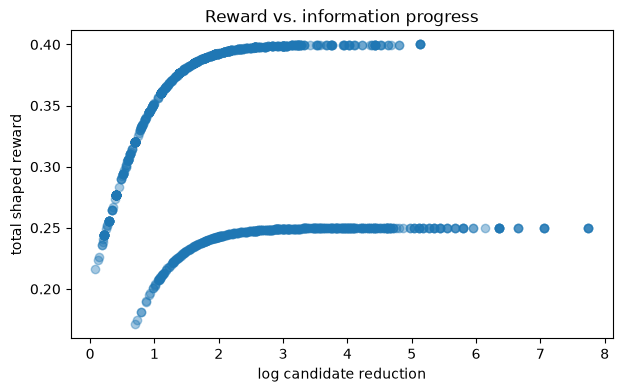

In [26]:
plt.figure(
    figsize=(7, 4)
)

plt.scatter(
    progress_df["progress"],
    progress_df["total_reward"],
    alpha=0.4,
)

plt.xlabel(
    "log candidate reduction"
)
plt.ylabel(
    "total shaped reward"
)
plt.title(
    "Reward vs. information progress"
)
plt.show()

## 10.20 Look explicitly for reward hacking

Now ask adversarial questions.

Could a policy get positive reward by:

- emitting any valid word repeatedly?
- making consistent but useless guesses?
- maximizing candidate reduction while never solving?
- producing malformed output after gaining early reward?
- exploiting a reward component with an unexpectedly large scale?

We can inspect the maximum contribution of each shaping term.

In [27]:
components = []

for state in expert_states[:200]:
    candidate_indices = (
        state["candidate_indices"]
    )

    sampled = rng.choice(
        candidate_indices,
        size=min(
            5,
            len(candidate_indices),
        ),
        replace=False,
    )

    for idx in sampled:
        action = evaluate_action(
            state["answer"],
            state["history"],
            ANSWERS[int(idx)],
        )

        reward = shaped_reward(
            action,
            turn_number=state["turn"],
            has_history=bool(
                state["history"]
            ),
        )

        components.append({
            "format": reward.format,
            "repeat": reward.repeat,
            "history": reward.history,
            "progress": reward.progress,
            "solve": reward.solve,
            "efficiency": reward.efficiency,
            "total": reward.total,
        })

components_df = pd.DataFrame(
    components
)

components_df.describe()

,format,repeat,history,progress,solve,efficiency,total
count,787.00,787.0,787.000000,787.000000,787.000000,787.000000,787.000000
mean,0.05,0.0,0.096633,0.166187,0.233799,0.031131,0.577750
std,0.00,0.0,0.071858,0.051058,0.643010,0.090569,0.729398
min,0.05,0.0,0.000000,0.000000,0.000000,0.000000,0.171160
25%,0.05,0.0,0.000000,0.160000,0.000000,0.000000,0.249306
50%,0.05,0.0,0.150000,0.190751,0.000000,0.000000,0.344828
75%,0.05,0.0,0.150000,0.198809,0.000000,0.000000,0.396873
max,0.05,0.0,0.150000,0.200000,2.000000,0.400000,2.799986


The intended scale hierarchy is roughly:

```text
solve bonus
    >>
individual shaping terms
```

If progress/history/format can add up to more than solving, the policy may prefer "looking good" over winning.

## 10.21 Sparse vs shaped reward

Compare the two reward philosophies.

Sparse:

```text
solve = 1
everything else = 0
```

Shaped:

```text
small intermediate rewards
+
large solve bonus
```

There is no universally correct answer.

Sparse rewards are cleaner but harder to learn from.

Shaped rewards provide denser credit assignment but introduce specification risk.

In [28]:
comparison = []

for name, guesses in trajectories.items():
    shaped = score_trajectory(
        "PLANT",
        guesses,
    )

    sparse_total = (
        1.0
        if shaped.solved
        else 0.0
    )

    comparison.append({
        "trajectory": name,
        "sparse_reward": sparse_total,
        "shaped_reward": shaped.total_reward,
        "solved": shaped.solved,
    })

pd.DataFrame(
    comparison
).sort_values(
    "shaped_reward",
    ascending=False,
)

,trajectory,sparse_reward,shaped_reward,solved
0,good,1.0,3.149322,True
4,slow_solve,1.0,2.369180,True
2,inconsistent,0.0,-0.946162,False
1,repeat,0.0,-1.250019,False
3,invalid,0.0,-1.500000,False


Sparse reward cannot distinguish:

```text
awful failed game
vs
nearly solved failed game
```

Both receive zero.

Shaping distinguishes them, which can accelerate early RL.

The price is that we must trust the shaping terms.

## 10.22 Freeze the Lab 11 reward contract

The first RL experiment should use one fixed reward function.

Do not tune weights while watching Lab 11 results unless the reward is clearly broken.

For Lab 11, freeze:

```text
valid format       +0.05 / -0.25
repeat             -0.20
history consistent ±0.15
candidate progress 0..+0.20
solve              +2.00
turn efficiency    0..+0.50
```

This is intentionally simple enough to reason about.

In [29]:
REWARD_CONFIG = {
    "valid_format": 0.05,
    "invalid_format": -0.25,
    "repeat": -0.20,
    "history_consistent": 0.15,
    "history_inconsistent": -0.15,
    "candidate_progress_scale": 0.20,
    "solve": 2.00,
    "turn_efficiency_per_saved_turn": 0.10,
}

REWARD_CONFIG

{'valid_format': 0.05,
 'invalid_format': -0.25,
 'repeat': -0.2,
 'history_consistent': 0.15,
 'history_inconsistent': -0.15,
 'candidate_progress_scale': 0.2,
 'solve': 2.0,
 'turn_efficiency_per_saved_turn': 0.1}

## 10.23 Persist the reward implementation

Lab 11 should import the reward function rather than copy notebook code.

Write:

```text
src/tiny_wordle/rewards.py
```

In [30]:
REWARDS_PATH = Path(
    "../src/tiny_wordle/rewards.py"
)

REWARDS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

reward_source = r'''from __future__ import annotations

from dataclasses import dataclass
import math


@dataclass
class RewardBreakdown:
    format: float
    repeat: float
    history: float
    progress: float
    solve: float
    efficiency: float

    @property
    def total(self) -> float:
        return (
            self.format
            + self.repeat
            + self.history
            + self.progress
            + self.solve
            + self.efficiency
        )


def candidate_reduction_value(
    before: int,
    after: int,
) -> float:
    if (
        before <= 0
        or after <= 0
    ):
        return 0.0

    return math.log(
        before / after
    )


def reward_breakdown(
    *,
    valid_format: bool,
    repeated: bool,
    history_consistent: bool,
    has_history: bool,
    solved: bool,
    candidates_before: int,
    candidates_after: int,
    turn_number: int,
) -> RewardBreakdown:
    format_reward = (
        0.05
        if valid_format
        else -0.25
    )

    repeat_reward = (
        -0.20
        if repeated
        else 0.0
    )

    if (
        has_history
        and valid_format
    ):
        history_reward = (
            0.15
            if history_consistent
            else -0.15
        )
    else:
        history_reward = 0.0

    if valid_format:
        reduction = (
            candidate_reduction_value(
                candidates_before,
                candidates_after,
            )
        )

        progress_reward = (
            0.20
            * math.tanh(
                reduction
            )
        )
    else:
        progress_reward = 0.0

    solve_reward = (
        2.0
        if solved
        else 0.0
    )

    efficiency_reward = (
        max(
            0.0,
            0.10 * (
                6 - turn_number
            ),
        )
        if solved
        else 0.0
    )

    return RewardBreakdown(
        format=format_reward,
        repeat=repeat_reward,
        history=history_reward,
        progress=progress_reward,
        solve=solve_reward,
        efficiency=efficiency_reward,
    )
'''

REWARDS_PATH.write_text(
    reward_source
)

print(
    "Wrote",
    REWARDS_PATH,
)

Wrote ../src/tiny_wordle/rewards.py


## 10.24 Preview how Lab 11 will use this

TRL's GRPO trainer supports custom reward functions that receive generated completions and return scalar rewards.

Lab 11 will wrap our Wordle environment around those completions:

```text
prompt/state
    ↓
model generates several guesses
    ↓
Wordle environment scores each guess
    ↓
reward function returns scalar values
    ↓
GRPO computes relative advantages
    ↓
policy update
```

GRPO is an online algorithm: it generates completions from the current policy, evaluates them, and updates the policy using relative rewards while constraining drift from a reference policy. citeturn363984search1turn363984search13

TRL supports user-defined custom reward functions, which is exactly the interface we will use in Lab 11. citeturn363984search2turn363984search7

# Lab 10 checkpoint

Send me:

1. the single-state action reward table;
2. the hand-built trajectory reward table;
3. `Hand-built reward ordering passed.`;
4. reward-vs-expert top-action agreement;
5. reward/progress correlation;
6. reward-component `describe()` table;
7. sparse-vs-shaped comparison;
8. confirmation that `rewards.py` was written.

The point of Lab 10 is not to find perfect coefficients.

It is to ensure that the reward has the right **ordering, scale, and failure modes** before Lab 11 starts optimizing it.